In [1]:
!pip install tensorflow opencv-python matplotlib --quiet


In [14]:
!ls /content/drive/MyDrive/archive/images | head


maksssksksss0.png
maksssksksss100.png
maksssksksss101.png
maksssksksss102.png
maksssksksss103.png
maksssksksss104.png
maksssksksss105.png
maksssksksss106.png
maksssksksss107.png
maksssksksss108.png


In [15]:
import os

base_dir = "/content/face_mask_data"
train_dir = os.path.join(base_dir, "Train")
test_dir = os.path.join(base_dir, "Test")

for dir_path in [train_dir, test_dir]:
    for cls in ["with_mask", "without_mask"]:
        os.makedirs(os.path.join(dir_path, cls), exist_ok=True)


In [ ]:
import shutil
import random

orig_dir = "/content/drive/MyDrive/archive/images"

# Classify images by name
with_mask_imgs = [f for f in os.listdir(orig_dir) if f.startswith("mak")]
without_mask_imgs = [f for f in os.listdir(orig_dir) if f.startswith("ak")]

# Function to split 80% train / 20% test
def split_and_copy(img_list, cls):
    random.shuffle(img_list)
    split_idx = int(len(img_list) * 0.8)
    train_imgs = img_list[:split_idx]
    test_imgs = img_list[split_idx:]

    for img in train_imgs:
        shutil.copy(os.path.join(orig_dir, img), os.path.join(train_dir, cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(orig_dir, img), os.path.join(test_dir, cls, img))

split_and_copy(with_mask_imgs, "with_mask")
split_and_copy(without_mask_imgs, "without_mask")


In [17]:
!ls /content/face_mask_data/Train/with_mask | head
!ls /content/face_mask_data/Train/without_mask | head
!ls /content/face_mask_data/Test/with_mask | head
!ls /content/face_mask_data/Test/without_mask | head


maksssksksss0.png
maksssksksss100.png
maksssksksss101.png
maksssksksss102.png
maksssksksss105.png
maksssksksss106.png
maksssksksss108.png
maksssksksss109.png
maksssksksss10.png
maksssksksss110.png
maksssksksss103.png
maksssksksss104.png
maksssksksss107.png
maksssksksss114.png
maksssksksss116.png
maksssksksss123.png
maksssksksss124.png
maksssksksss127.png
maksssksksss133.png
maksssksksss136.png


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Only rescaling for testing
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = "/content/face_mask_data/Train"
test_dir = "/content/face_mask_data/Test"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary'
)


Found 227 images belonging to 2 classes.
Found 57 images belonging to 2 classes.


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10,  # small dataset; increase if needed
    steps_per_epoch=len(train_generator),
    validation_steps=len(test_generator)
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8618 - loss: 0.1645 - val_accuracy: 1.0000 - val_loss: 2.3675e-21
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 1.5397e-19 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 1.0000 - loss: 2.3727e-32 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 1.0000 - loss: 0.000

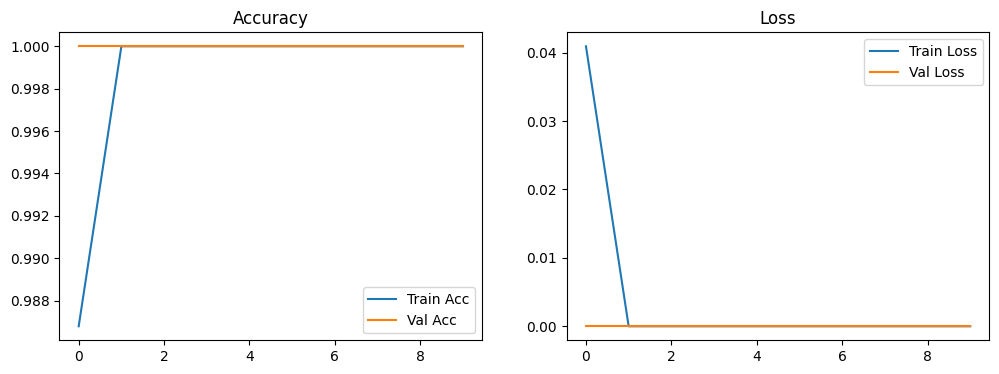

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()


In [22]:
model.save("face_mask_detector.h5")


In [26]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to a real image in Test folder
img_path = "/content/face_mask_data/Test/with_mask/maksssksksss103.png"

# Load and preprocess the image
img = image.load_img(img_path, target_size=(128,128))
img_array = np.expand_dims(image.img_to_array(img)/255.0, axis=0)

# Predict
pred = model.predict(img_array)[0][0]
label = "Mask" if pred > 0.5 else "No Mask"
print(f"Prediction: {label} (prob={pred:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Prediction: No Mask (prob=0.00)
